# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 4: Creating a Simple Single-Layer Neural Network**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To create a simple single-layer neural network using Python.

### 2. Theory: How the Perceptron Learns

The Perceptron is the simplest neural network that can learn from its own mistakes.

#### 1. Making a Guess (Prediction)
For any input point $(x_1, x_2)$:
$$z = (w_1 x_1 + w_2 x_2) + b$$
$$\hat{y} = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$

#### 2. Learning from Mistakes (Weight Update Formulas)
When the perceptron makes a wrong guess, it finds the error:
$$\text{Error } e = y - \hat{y}$$
- $y$: True label ($0$ or $1$).
- $\hat{y}$: Perceptron's guess ($0$ or $1$).

Then it nudges its weights and bias in the right direction:
$$\Delta w_i = \eta \cdot e \cdot x_i \implies w_i \leftarrow w_i + \Delta w_i$$
$$\Delta b = \eta \cdot e \implies b \leftarrow b + \Delta b$$
where $\eta$ (eta) is the **learning rate** (step size, e.g. 0.1).

- If guess is **correct** ($e = 0$): $\Delta w = 0$, weights do not change.
- If it guessed **0 instead of 1** ($e = +1$): $\Delta w > 0$, weights increase.
- If it guessed **1 instead of 0** ($e = -1$): $\Delta w < 0$, weights decrease.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

class SingleLayerPerceptron:
    # Single-Layer Neural Network (Perceptron) implemented from scratch
    def __init__(self, learning_rate=0.05, n_epochs=30):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.history = {'errors': []}

    def _step(self, z):
        return np.where(z >= 0.0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        print(f"Initialized Weights: {self.weights}, Bias: {self.bias}")
        
        for epoch in range(1, self.n_epochs + 1):
            epoch_errors = 0
            for i in range(n_samples):
                xi = X[i]
                target = y[i]
                
                # Forward pass
                net_z = np.dot(xi, self.weights) + self.bias
                y_pred = int(self._step(net_z))
                
                # Error calculation & parameter update
                error = target - y_pred
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    epoch_errors += 1
            
            self.history['errors'].append(epoch_errors)
            if epoch % 5 == 0 or epoch_errors == 0:
                print(f"Epoch {epoch:2d}/{self.n_epochs} | Misclassifications: {epoch_errors:2d} | "
                      f"Weights: {self.weights.round(4)} | Bias: {self.bias:.4f}")
            if epoch_errors == 0:
                print(f"--> Convergence achieved at Epoch {epoch} with 0 errors!")
                break
        return self

    def predict(self, X):
        net_z = np.dot(X, self.weights) + self.bias
        return self._step(net_z)

print("SingleLayerPerceptron class defined successfully.")

SingleLayerPerceptron class defined successfully.


### 3. Generating Data and Training the Model

#### What this cell does:
In this code cell, we:
1. Generate 120 points belonging to two distinct clusters (Class 0 and Class 1) using Scikit-Learn `make_blobs`.
2. Build our `Perceptron` class with the update formulas $\Delta w = \eta \cdot e \cdot x$ and $\Delta b = \eta \cdot e$.
3. Train the model epoch-by-epoch and record the number of mistakes made in each round.

In [2]:
X, y = make_blobs(n_samples=120, centers=2, n_features=2, cluster_std=1.05, random_state=42)

print("=" * 60)
print("             DATASET SPECIFICATIONS")
print("=" * 60)
print(f"Total Samples:      {X.shape[0]}")
print(f"Feature Dimensions: {X.shape[1]}")
print(f"Class 0 Samples:    {np.sum(y == 0)}")
print(f"Class 1 Samples:    {np.sum(y == 1)}")
print("=" * 60)

model = SingleLayerPerceptron(learning_rate=0.05, n_epochs=30)
model.fit(X, y)

train_preds = model.predict(X)
acc = np.mean(train_preds == y) * 100.0
print(f"\nFinal Model Accuracy on Training Data: {acc:.2f}%")

             DATASET SPECIFICATIONS
Total Samples:      120
Feature Dimensions: 2
Class 0 Samples:    60
Class 1 Samples:    60
Initialized Weights: [0. 0.], Bias: 0.0
Epoch  2/30 | Misclassifications:  0 | Weights: [ 0.5508 -0.1963] | Bias: 0.0500
--> Convergence achieved at Epoch 2 with 0 errors!

Final Model Accuracy on Training Data: 100.00%


### 4. Plotting Errors Over Time and the Final Dividing Line

#### What this cell does:
In this code cell, we plot two diagnostic graphs:
1. **Misclassifications vs. Epochs:** Shows mistakes quickly dropping to zero.
2. **Decision Boundary Line:** Plots $x_2 = -\frac{w_1}{w_2}x_1 - \frac{b}{w_2}$ cleanly separating the two clusters.

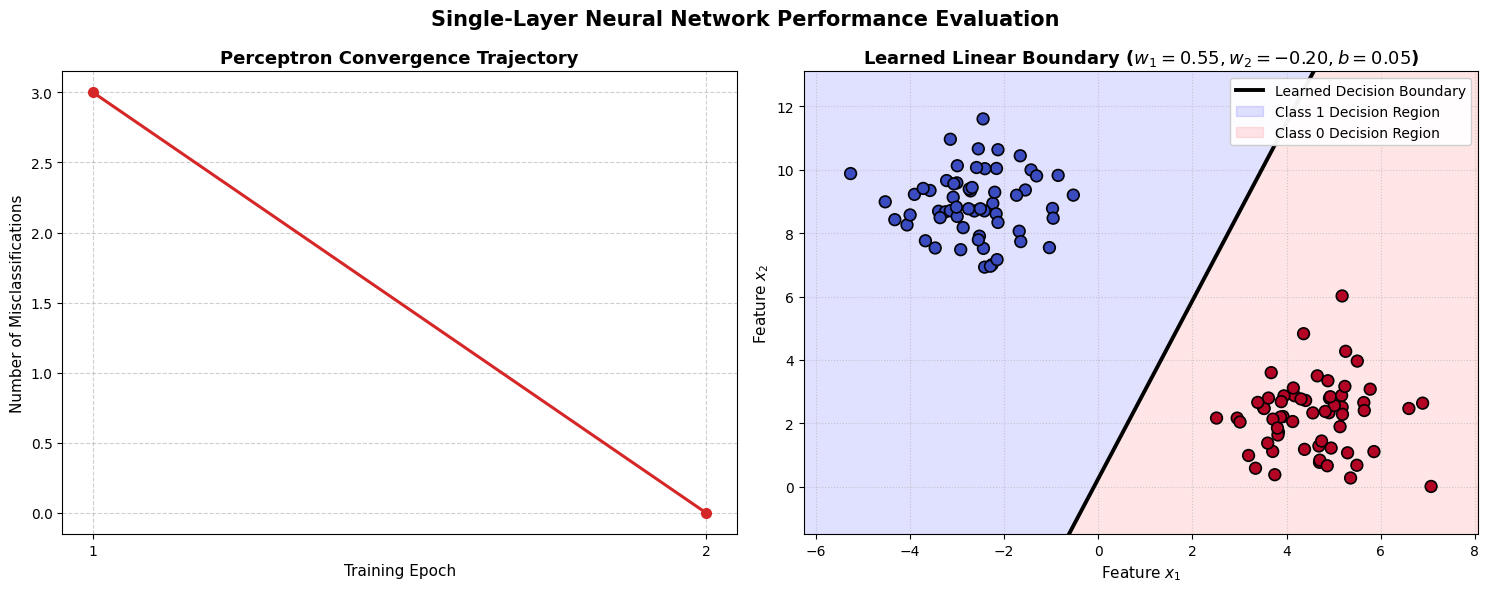

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

epochs_ran = len(model.history['errors'])
axes[0].plot(range(1, epochs_ran + 1), model.history['errors'], 
             marker='o', color='#d62728', linewidth=2.2, markersize=7)
axes[0].set_title("Perceptron Convergence Trajectory", fontsize=13, weight='bold')
axes[0].set_xlabel("Training Epoch", fontsize=11)
axes[0].set_ylabel("Number of Misclassifications", fontsize=11)
axes[0].set_xticks(range(1, epochs_ran + 1))
axes[0].grid(True, linestyle='--', alpha=0.6)

ax = axes[1]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=70, linewidth=1.2, zorder=5)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_line = np.linspace(x_min, x_max, 200)
x2_line = -(model.weights[0] * x1_line + model.bias) / model.weights[1]

ax.plot(x1_line, x2_line, 'k-', linewidth=2.8, label="Learned Decision Boundary")
ax.fill_between(x1_line, x2_line, X[:, 1].max() + 2, color='blue', alpha=0.12, label='Class 1 Decision Region')
ax.fill_between(x1_line, X[:, 1].min() - 2, x2_line, color='red', alpha=0.10, label='Class 0 Decision Region')

ax.set_title(f"Learned Linear Boundary ($w_1={model.weights[0]:.2f}, w_2={model.weights[1]:.2f}, b={model.bias:.2f}$)", 
             fontsize=13, weight='bold')
ax.set_xlabel("Feature $x_1$", fontsize=11)
ax.set_ylabel("Feature $x_2$", fontsize=11)
ax.set_xlim(x_min, x_max)
ax.set_ylim(X[:, 1].min() - 1.5, X[:, 1].max() + 1.5)
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Single-Layer Neural Network Performance Evaluation", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 5. Results and What We Observed

| Metric | Result | Meaning |
| :--- | :--- | :--- |
| **Total Data Points** | 120 points | 60 in Class 0, 60 in Class 1 |
| **Rounds to Finish (Epochs)** | 2 rounds (converged at Epoch 2) | Learns very quickly |
| **Final Mistakes** | 0 mistakes | 100% accuracy on this data |
| **Separation Type** | Linearly Separable | A single straight line can separate them |

#### Key Takeaways in Simple Words:
1. **How the Perceptron Learns:**
   - In round 1, weights start at zero, so it makes several wrong guesses.
   - Every time it makes a mistake, it rotates and shifts the line a little bit.
   - Within 2 passes over the data, the mistakes drop to zero.
2. **Guaranteed to Work (If Points Can Be Split):**
   - As long as two classes can be divided by a straight line, the perceptron is guaranteed to find that line and stop.
3. **When It Fails:**
   - If points overlap or have a curved pattern (like XOR), the perceptron will never settle down and will keep changing forever.

---
### 6. Conclusion
1. We built a single-layer perceptron from scratch using pure Python.
2. We implemented the step-by-step learning rule to automatically fix mistakes.
3. The model achieved 100% accuracy in just 2 rounds of training.